# Exercises XP Gold - K-means from scratch

## What you will create
- A K-means implementation in pure NumPy.
- Scatter plots of clusters and centroid convergence.
- A report with cluster assignments per point.
- A random centroid initializer to study initialization impact.

## What you will learn
- Euclidean distance and closest-centroid assignment.
- How centroid updates reduce within-cluster variance.
- Why initialization matters and how to evaluate runs.


## Task 1 - Load and visualize the dataset
Dataset: `ex7data2.mat` contains an array `X` of shape (m, 2).

- Load with `scipy.io.loadmat`
- Inspect shape and preview first rows
- Scatter plot of points

Shape of X: (300, 2)
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


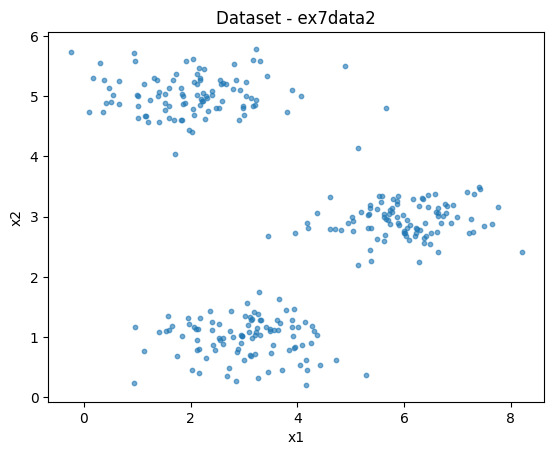

In [2]:
# Load X from the .mat file
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)
# The .mat file contains a key 'X' with the array of points
X = data['X']
print('Shape of X:', X.shape)
# Preview first 5 rows
print(X[:5])

# Scatter plot
plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)
plt.title('Dataset - ex7data2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Task 2 - Finding closest centroids
Implement `find_closest_centroids(X, centroids)`.

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances

Test with initial centroids = `np.array([[3, 3], [6, 2], [8, 5]])` and print the first three indices.

In [4]:
def find_closest_centroids(X, centroids):
    """Return idx of shape (m,) with index of closest centroid for each point."""
    # X: (m, n), centroids: (K, n)
    # Expand dims to broadcast: (m, 1, n) - (K, n) -> (m, K, n)
    distances = np.sum((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2, axis=2)  # (m, K)
    idx = np.argmin(distances, axis=1)  # (m,)
    return idx

# Test
import numpy as np
init_centroids = np.array([[3,3],[6,2],[8,5]], dtype=float)
idx = find_closest_centroids(X, init_centroids)
print(idx[:3])  # Expected: [0, 2, 1]

[0 2 1]


## Task 3 - Computing centroids
Implement `compute_centroids(X, idx, K)`.

- For each k in 0..K-1 compute the mean of points assigned to k
- Return `centroids` of shape (K, n)
- If a cluster is empty, reinitialize its centroid by sampling a random point from X

In [5]:
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.shape[0] == 0:
            # Empty cluster: reinitialize with a random point from X
            new_centroids[k] = X[rng.integers(m)]
        else:
            new_centroids[k] = pts.mean(axis=0)
    return new_centroids

# Test
idx_test = find_closest_centroids(X, init_centroids)
print(compute_centroids(X, idx_test, K=3))

[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


## Task 4 - Running K-means
Implement `run_k_means(X, init_centroids, max_iters)`.

- Loop: assign then update
- Keep history of centroids for plotting
- Return final centroids, idx, and history list
- Run for 10 iterations and plot clusters with final centroids

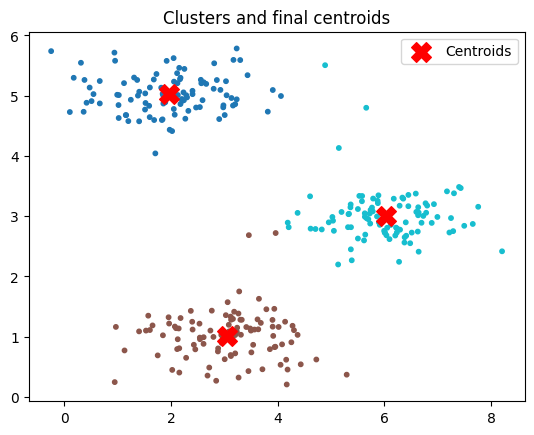

In [6]:
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None
    for it in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, K, rng=rng)
        history.append(centroids.copy())
    return centroids, idx, history

# Run for 10 iterations
final_centroids, idx, hist = run_k_means(X, init_centroids, max_iters=10)

# Plot clusters with final centroids
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=idx, s=10, cmap='tab10')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('Clusters and final centroids')
plt.legend()
plt.show()

## Task 5 - Initializing centroids
Implement `init_centroids(X, K, rng)` that picks K distinct random points from X.

Test by printing initial centroids for K = 3.

In [7]:
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    # Pick K distinct random row indices
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)

# Test
print(init_centroids(X, 3))

[[6.11768055 2.85475655]
 [3.43493543 5.34080741]
 [5.50295759 2.62924634]]


## Task 6 - Multiple initializations and evaluation
Define an inertia function `withinss(X, centroids, idx)` to compute the sum of squared distances to centroids.

- Run K-means for several random seeds
- Keep the run with lowest inertia
- Save a CSV report with x1, x2, cluster label

Seed 0: inertia = 266.66
Seed 1: inertia = 266.66
Seed 2: inertia = 266.66
Seed 3: inertia = 858.41
Seed 4: inertia = 266.66

Best inertia: 266.65851965491936
Wrote kmeans_assignments.csv


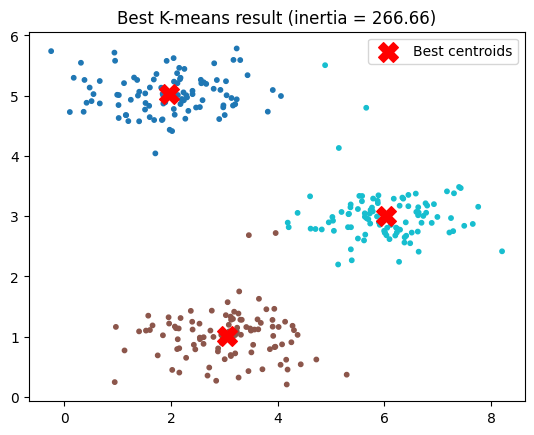

In [11]:
import pandas as pd

def withinss(X, centroids, idx):
    # For each point, compute squared distance to its assigned centroid
    diffs = X - centroids[idx]
    return float(np.sum(diffs * diffs))

# Multi-start: run 5 times with different seeds, keep best
best = {'score': np.inf}
for seed in range(5):
    rng = np.random.default_rng(seed)
    c0 = init_centroids(X, 3, rng)
    cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
    s = withinss(X, cF, idxF)
    print(f'Seed {seed}: inertia = {s:.2f}')
    if s < best['score']:
        best = {'score': s, 'centroids': cF, 'idx': idxF}

print('\nBest inertia:', best['score'])

# Save CSV report
rep = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'cluster': best['idx']})
rep.to_csv('kmeans_assignments.csv', index=False)
print('Wrote kmeans_assignments.csv')

# Plot best result
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=best['idx'], s=10, cmap='tab10')
plt.scatter(best['centroids'][:, 0], best['centroids'][:, 1], marker='X', s=200, c='red', label='Best centroids')
plt.title(f"Best K-means result (inertia = {best['score']:.2f})")
plt.legend()
plt.show()